Mask shape: (33, 25)


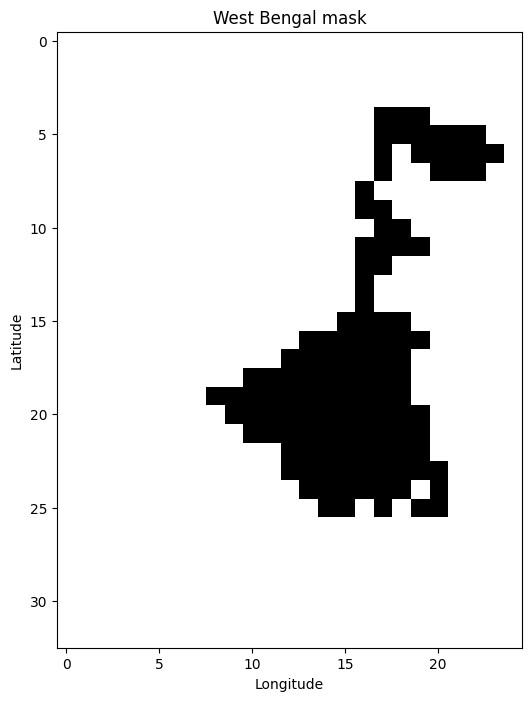

In [2]:
import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Paths
nc_path = r"F:\IIT KGP\sem10\MTP 2\ERA5_Evaporation\ERA5_Evaporation_2001.nc"
shp_path = r"F:\IIT KGP\sem10\MTP 2\WB_Shape_file\West Bengal\District_shape_West_Bengal.shp"

# Open one ERA5 .nc file
ds = xr.open_dataset(nc_path, engine="netcdf4")

# Extract lat/lon grid
lats = ds["latitude"].values      # 33 values
lons = ds["longitude"].values     # 25 values

# Read shapefile and convert to WGS84 lat-lon if needed
wb = gpd.read_file(shp_path).to_crs("EPSG:4326")

# Merge all district polygons into one West Bengal geometry
wb_geom = wb.union_all()

# Create mask: 1 inside WB, 0 outside
mask = np.zeros((len(lats), len(lons)), dtype=np.uint8)

for i, lat in enumerate(lats):
    for j, lon in enumerate(lons):
        pt = Point(float(lon), float(lat))
        if wb_geom.covers(pt):   # includes boundary points too
            mask[i, j] = 1

print("Mask shape:", mask.shape)
# print(mask)

# Plot
plt.figure(figsize=(6, 8))
plt.imshow(
    mask,
    origin="upper",
    cmap="gray_r",
    aspect="auto"
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("West Bengal mask")
plt.show()

In [3]:
np.save("WB_mask.npy", mask)

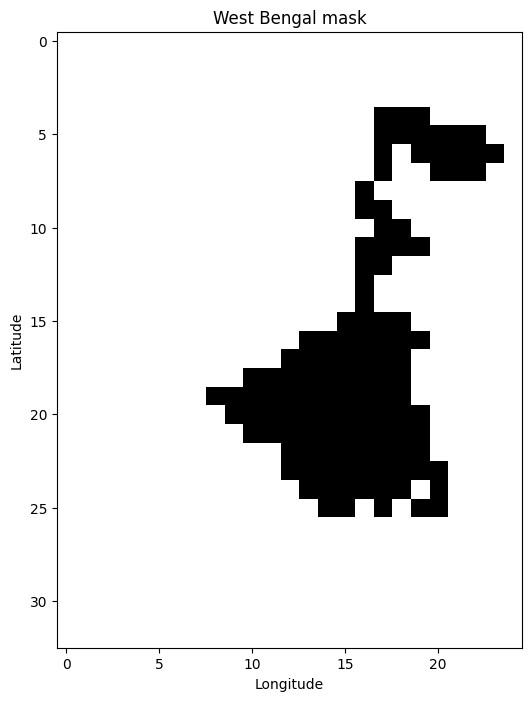

In [5]:
data = np.load("WB_mask.npy")
#plot it
plt.figure(figsize=(6, 8))
plt.imshow(
    data,
    origin="upper",
    cmap="gray_r",
    aspect="auto"
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("West Bengal mask")
plt.show()